/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_70721/36544261.py:8: DtypeWarning: Columns (8,31,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/FINAL_merged_collar_herde_weather_bolus.csv")


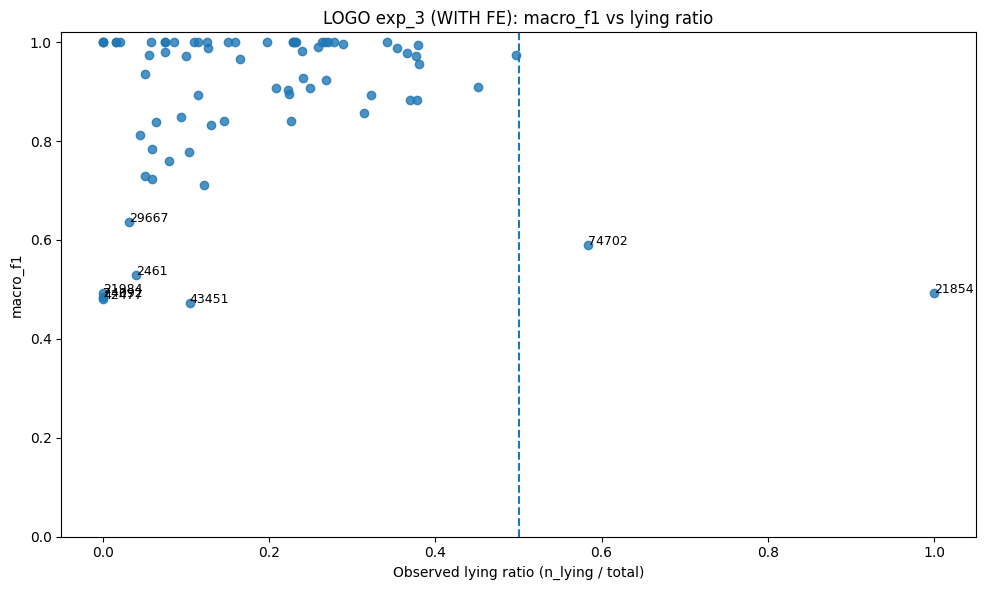

,cow_id,macro_f1,balanced_accuracy,f1_lying,f1_standing,n_lying,n_standing,lying_ratio,is_pure
41,43451,0.472,0.500000,0.000000,0.944928,19,163,0.104396,False
39,42477,0.481,0.925373,0.000000,0.961240,0,134,0.000000,True
48,74092,0.484,0.938547,0.000000,0.968300,0,179,0.000000,True
23,21984,0.492,0.969072,0.000000,0.984293,0,194,0.000000,True
21,21854,0.493,0.970588,0.985075,0.000000,34,0,1.000000,True
29,2461,0.530,0.856870,0.226804,0.832962,11,262,0.040293,False
49,74702,0.589,0.665842,0.498141,0.680851,202,144,0.583815,False
36,29667,0.636,0.583333,0.285714,0.986877,6,188,0.030928,False
30,2462,0.712,0.653846,0.470588,0.954082,26,187,0.122066,False
37,42471,0.724,0.913414,0.508475,0.939457,16,253,0.059480,False


In [24]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/FINAL_merged_collar_herde_weather_bolus.csv")
df['Stehen/Liegen'] = df['Stehen/Liegen'].map({'Liegen': 0, 'Stehen': 1})
imu = ['IMU_Tick_Count_40mG', 'IMU_Tick_Count_80mG',
       'IMU_Tick_Count_120mG', 'IMU_Tick_Count_160mG', 'IMU_Tick_Count_200mG',
       'IMU_Tick_Count_240mG']

df = df[df[imu].sum(axis=1) != 0]

# -----------------------
# Config
# -----------------------
LABEL_COL = "Stehen/Liegen"  # your label column in df
COW_COL = "animal_id"        # change if your cow id column has a different name

RESULTS_PATH = Path("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_5_FINAL_merged_collar_herde_weather_bolus/results.json")

# Map your labels to 0/1 if needed.
# Assumption: df[LABEL_COL] already contains 0/1 with 0=lying, 1=standing (based on your earlier code).
# If df has strings like "Liegen"/"Stehen", set this mapping accordingly.
LABEL_MAPPING = None
# Example if strings:
# LABEL_MAPPING = {"Liegen": 0, "Stehen": 1}


# -----------------------
# Load LOGO per-cow results
# -----------------------
with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

res_rows = []
for cow_id_str, m in results.items():
    row = {"cow_id": int(cow_id_str)}
    row.update(m)
    res_rows.append(row)

res_df = pd.DataFrame(res_rows)

# keep only the columns we care about (add others if you want)
keep_cols = ["cow_id", "macro_f1", "balanced_accuracy", "f1_lying", "f1_standing",
             "support_lying", "support_standing"]
keep_cols = [c for c in keep_cols if c in res_df.columns]
res_df = res_df[keep_cols].copy()


# -----------------------
# Build per-cow class representation from df
# -----------------------
work = df.copy()

if LABEL_MAPPING is not None:
    work[LABEL_COL] = work[LABEL_COL].map(LABEL_MAPPING)

# Basic checks
if work[LABEL_COL].isna().any():
    raise ValueError("Some labels became NaN after mapping. Check LABEL_MAPPING or label values.")
if COW_COL not in work.columns:
    raise ValueError(f"{COW_COL=} not found in df.columns. Available: {list(work.columns)[:30]} ...")

# Per-cow counts
counts = (
    work.groupby(COW_COL)[LABEL_COL]
    .value_counts(dropna=False)
    .unstack(fill_value=0)
)

# Determine which label is "lying" and which is "standing"
# Here we assume: 0=lying, 1=standing
if 0 not in counts.columns or 1 not in counts.columns:
    raise ValueError(
        "Expected binary labels 0/1 in df[LABEL_COL]. "
        f"Found columns: {list(counts.columns)}. "
        "If your labels are strings, set LABEL_MAPPING."
    )

repr_df = pd.DataFrame({
    "cow_id": counts.index.astype(int),
    "n_lying": counts[0].astype(int),
    "n_standing": counts[1].astype(int),
})
repr_df["n_total"] = repr_df["n_lying"] + repr_df["n_standing"]
repr_df["lying_ratio"] = np.where(repr_df["n_total"] > 0, repr_df["n_lying"] / repr_df["n_total"], np.nan)
repr_df["is_pure"] = (repr_df["n_lying"] == 0) | (repr_df["n_standing"] == 0)


# -----------------------
# Merge representation with LOGO results
# -----------------------
merged = res_df.merge(repr_df, on="cow_id", how="left")

# sanity check for missing cows
missing = merged["n_total"].isna().sum()
if missing:
    print(f"Warning: {missing} cows in results.json not found in df (cow_id mismatch?)")


# -----------------------
# Plot: per-cow performance vs class representation
# -----------------------
def plot_score_vs_representation(
    merged_df: pd.DataFrame,
    score_col: str = "macro_f1",
    annotate_k: int = 8,
    title: str | None = None
):
    plot_df = merged_df.dropna(subset=[score_col, "lying_ratio"]).copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(plot_df["lying_ratio"], plot_df[score_col], alpha=0.8)

    # Add reference line at lying_ratio=0.5
    plt.axvline(0.5, linestyle="--")

    plt.xlabel("Observed lying ratio (n_lying / total)")
    plt.ylabel(score_col)
    plt.ylim(0, 1.02)

    if title is None:
        title = f"{score_col} vs lying ratio (one point per cow)"
    plt.title(title)

    # annotate worst k cows by score
    worst = plot_df.nsmallest(annotate_k, score_col)
    for _, r in worst.iterrows():
        plt.text(r["lying_ratio"], r[score_col], str(int(r["cow_id"])), fontsize=9)

    plt.tight_layout()
    plt.show()


plot_score_vs_representation(
    merged,
    score_col="macro_f1",
    annotate_k=8,
    title="LOGO exp_3 (WITH FE): macro_f1 vs lying ratio"
)


# -----------------------
# Optional: show tail table for interpretation
# -----------------------
tail = merged.sort_values("macro_f1", ascending=True).head(20)
tail_cols = ["cow_id", "macro_f1", "balanced_accuracy", "f1_lying", "f1_standing",
             "n_lying", "n_standing", "lying_ratio", "is_pure"]
tail_cols = [c for c in tail_cols if c in tail.columns]
tail[tail_cols]


In [26]:
merged

,cow_id,macro_f1,balanced_accuracy,f1_lying,f1_standing,support_lying,support_standing,n_lying,n_standing,n_total,lying_ratio,is_pure
0,15543,1.000,1.000000,1.000000,1.000000,70.0,188.0,70,188,258,0.271318,False
1,15546,0.990,0.984848,0.984615,0.994737,66.0,189.0,66,189,255,0.258824,False
2,15547,0.956,0.946721,0.943723,0.968370,122.0,199.0,122,199,321,0.380062,False
3,15554,0.909,0.902516,0.891986,0.925659,159.0,193.0,159,193,352,0.451705,False
4,15555,0.839,0.802457,0.695652,0.981818,13.0,191.0,13,191,204,0.063725,False
...,...,...,...,...,...,...,...,...,...,...,...,...
67,99731,1.000,1.000000,NaN,1.000000,NaN,140.0,0,140,140,0.000000,True
68,99735,1.000,1.000000,1.000000,1.000000,3.0,186.0,3,186,189,0.015873,False
69,99738,1.000,1.000000,1.000000,1.000000,19.0,203.0,19,203,222,0.085586,False
70,99739,1.000,1.000000,1.000000,1.000000,27.0,188.0,27,188,215,0.125581,False


In [30]:
df[['animal_id', 'datetime', 'behaviour_1', 'IMU_Tick_Count_40mG', 'IMU_Tick_Count_80mG', 'IMU_Tick_Count_120mG', 'IMU_Tick_Count_160mG', 'IMU_Tick_Count_200mG', 'IMU_Tick_Count_240mG']]

,animal_id,datetime,behaviour_1,IMU_Tick_Count_40mG,IMU_Tick_Count_80mG,IMU_Tick_Count_120mG,IMU_Tick_Count_160mG,IMU_Tick_Count_200mG,IMU_Tick_Count_240mG
0,2452,2024-07-08 12:27:00,Liegen,156.0,59.0,25.0,8.0,6.0,2.0
1,2452,2024-07-08 12:28:00,Liegen,162.0,76.0,40.0,26.0,21.0,17.0
2,2452,2024-07-08 12:29:00,Liegen,156.0,75.0,44.0,31.0,24.0,19.0
3,2452,2024-07-08 12:30:00,Stehen/Laufen,173.0,116.0,88.0,66.0,50.0,38.0
4,2452,2024-07-08 12:31:00,Stehen/Laufen,215.0,182.0,125.0,93.0,76.0,59.0
...,...,...,...,...,...,...,...,...,...
17556,99741,2024-09-12 10:04:00,Liegen,89.0,5.0,0.0,0.0,0.0,0.0
17557,99741,2024-09-12 10:05:00,Liegen,83.0,20.0,6.0,3.0,2.0,2.0
17558,99741,2024-09-12 10:06:00,Liegen,71.0,3.0,0.0,0.0,0.0,0.0
17559,99741,2024-09-12 10:07:00,Liegen,76.0,6.0,3.0,0.0,0.0,0.0


In [32]:
df.behaviour_1.value_counts(dropna=False)

behaviour_1
Stehen/Laufen    12865
Liegen            3363
Stehen             715
Name: count, dtype: int64

In [11]:
logo_1_path = Path("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_1_FINAL_merged_collar_herde_weather/results.json")
logo_1_bolus_path = Path("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_1_FINAL_merged_collar_herde_weather_bolus/results.json")
logo_3_path = Path("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_3_FINAL_merged_collar_herde_weather/results.json")
logo_3_bolus_path = Path("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_3_FINAL_merged_collar_herde_weather_bolus/results.json")
logo_4_bolus_path = Path("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_4_FINAL_merged_collar_herde_weather_bolus/results.json")
logo_5_bolus_path = Path("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_5_FINAL_merged_collar_herde_weather_bolus/results.json")

def open_results(path):
    # -----------------------
    # Load LOGO per-cow results
    # -----------------------
    with open(path, "r") as f:
        results = json.load(f)

    res_rows = []
    for cow_id_str, m in results.items():
        row = {"cow_id": int(cow_id_str)}
        row.update(m)
        res_rows.append(row)

    res_df = pd.DataFrame(res_rows)

    # keep only the columns we care about (add others if you want)
    keep_cols = ["cow_id", "macro_f1", "balanced_accuracy", "f1_lying", "f1_standing",
                "support_lying", "support_standing"]
    keep_cols = [c for c in keep_cols if c in res_df.columns]
    res_df = res_df[keep_cols].copy()
    print(f"Macro F1 mean: {res_df.macro_f1.mean():.2f} ± {res_df.macro_f1.std():.2f}")
    print(f"F1 standing mean: {res_df.f1_standing.mean():.2f} ± {res_df.f1_standing.std():.2f}")
    print(f"F1 lying mean: {res_df.f1_lying.mean():.2f} ± {res_df.f1_lying.std():.2f}")
    print(f"Balanced Accuracy mean: {res_df.balanced_accuracy.mean():.2f} ± {res_df.balanced_accuracy.std():.2f}")
    return res_df


In [13]:
print("Full dataset baseline:")
logo_1_results = open_results(logo_1_path)

print("Full dataset weather: ")
logo_3_results = open_results(logo_3_path)

print("Bolus subset baseline:")
logo_1_bolus_results = open_results(logo_1_bolus_path)

print("Bolus subset weather:")
logo_3_bolus_results = open_results(logo_3_bolus_path)

print("Bolus subset bolus:")
logo_4_bolus_results = open_results(logo_4_bolus_path)

print("Bolus subset collar + bolus + weather:")
logo_5_bolus_results = open_results(logo_5_bolus_path)

Full dataset baseline:
Macro F1 mean: 0.8479711538461537
F1 standing mean: 0.9492206595222075
F1 lying mean: 0.7441918608238529
Balanced Accuracy mean: 0.8988730879682127
Full dataset weather: 
Macro F1 mean: 0.8885769230769232
F1 standing mean: 0.964593744353201
F1 lying mean: 0.8088936565227305
Balanced Accuracy mean: 0.9248952108617854
Bolus subset baseline:
Macro F1 mean: 0.8341527777777779
F1 standing mean: 0.9389626947743059
F1 lying mean: 0.7293901828516642
Balanced Accuracy mean: 0.8901284773355537
Bolus subset weather:
Macro F1 mean: 0.8618472222222223
F1 standing mean: 0.951464418463321
F1 lying mean: 0.7690678727161695
Balanced Accuracy mean: 0.9046904497236459
Bolus subset bolus:
Macro F1 mean: 0.8303333333333334
F1 standing mean: 0.9506428824060231
F1 lying mean: 0.7009493496945276
Balanced Accuracy mean: 0.868328263342472
Bolus subset collar + bolus + weather:
Macro F1 mean: 0.8905138888888889
F1 standing mean: 0.9583443418218395
F1 lying mean: 0.814969779008495
Balanced 

/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_70721/3451101461.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Collar", "Collar + Bolus", "Collar + Bolus \n+ Weather"])


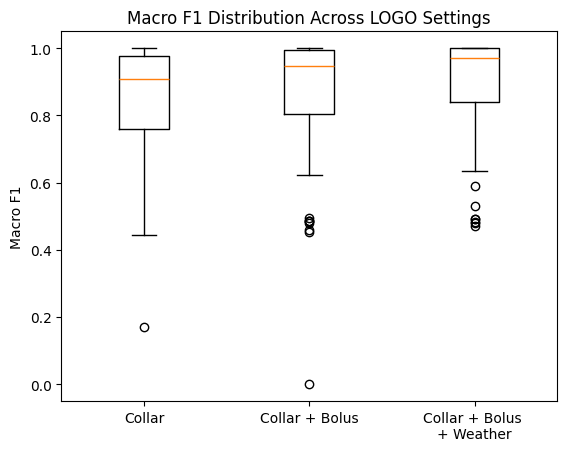

In [22]:
logo_1_results

In [5]:
plt.figure(figsize=(8, 5))
data = [
    logo_1_bolus_results["macro_f1"].dropna(),
    logo_3_bolus_results["macro_f1"].dropna(),
    logo_5_bolus_results["macro_f1"].dropna(),
]
plt.boxplot(data, labels=["Baseline", "Weather", "Collar+Bolus+Weather"])
plt.ylabel("Macro F1")
plt.title("Macro F1 distribution across LOGO bolus experiments")
plt.tight_layout()
plt.show()print()
merged.macro_f1.mean()

np.float64(0.8341527777777779)

In [6]:
merged.f1_lying.mean()

np.float64(0.7293901828516642)

In [7]:
merged.f1_standing.mean()

np.float64(0.9389626947743059)

In [5]:
cow = 21854

# 1) From full df
sub_full = df[df["animal_id"] == cow]
ratio_full = (sub_full["Stehen/Liegen"] == 0).mean()

# 2) From repr_df used in the plot
repr_row = repr_df[repr_df["cow_id"] == cow]
ratio_repr = repr_row["lying_ratio"].iloc[0]

# 3) From results.json (LOGO test fold)
res_row = res_df[res_df["cow_id"] == cow]
ratio_logo = res_row["support_lying"].iloc[0] / (
    res_row["support_lying"].iloc[0] + res_row["support_standing"].iloc[0]
)

ratio_full, ratio_repr, ratio_logo


(np.float64(0.2446043165467626),
 np.float64(0.2446043165467626),
 np.float64(1.0))

In [8]:
df[df["animal_id"] == 21854]

,neckband,animal_id,datetime,date,time,behaviour_1,Stehen/Liegen,behaviour_2,comments,Unix_Timestamp,...,SolarVolt2_Min,SolarVolt2_Avg,SolarVolt2_Max,SolarVolt2_Std,HeaterVolt2_Min,HeaterVolt2,HeaterVolt2_Max,PowerOn2_Min,PowerOn2,PowerOn2_Max
244,2473900771,21854,2024-07-19 09:06:00,19.07.2024,09:06:00,Liegen,0,NaN,NaN,2024-07-19 09:06:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
245,2473900771,21854,2024-07-19 09:07:00,19.07.2024,09:07:00,Liegen,0,NaN,NaN,2024-07-19 09:07:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
246,2473900771,21854,2024-07-19 09:08:00,19.07.2024,09:08:00,Liegen,0,NaN,NaN,2024-07-19 09:08:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
247,2473900771,21854,2024-07-19 09:09:00,19.07.2024,09:09:00,Liegen,0,NaN,NaN,2024-07-19 09:09:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
248,2473900771,21854,2024-07-19 09:10:00,19.07.2024,09:10:00,Liegen,0,NaN,NaN,2024-07-19 09:10:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
249,2473900771,21854,2024-07-19 09:11:00,19.07.2024,09:11:00,Liegen,0,NaN,NaN,2024-07-19 09:11:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
250,2473900771,21854,2024-07-19 09:12:00,19.07.2024,09:12:00,Liegen,0,NaN,NaN,2024-07-19 09:12:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
251,2473900771,21854,2024-07-19 09:13:00,19.07.2024,09:13:00,Liegen,0,NaN,NaN,2024-07-19 09:13:00+00:00,...,21938.18,22081.50,22371.60,127.49200,12233.33,12234.22,12237.75,4973.0,4973.0,4973.0
252,2473900771,21854,2024-07-19 09:16:00,19.07.2024,09:16:00,Liegen,0,NaN,NaN,2024-07-19 09:16:00+00:00,...,22079.68,22317.44,22453.79,105.19580,12232.78,12235.99,12237.69,4973.0,4973.0,4973.0
253,2473900771,21854,2024-07-19 09:17:00,19.07.2024,09:17:00,Liegen,0,NaN,NaN,2024-07-19 09:17:00+00:00,...,22079.68,22317.44,22453.79,105.19580,12232.78,12235.99,12237.69,4973.0,4973.0,4973.0


In [ ]:
df[df["animal_id"] == 43451]

,neckband,animal_id,datetime,date,time,behaviour_1,Stehen/Liegen,behaviour_2,comments,Unix_Timestamp,...,SolarVolt2_Min,SolarVolt2_Avg,SolarVolt2_Max,SolarVolt2_Std,HeaterVolt2_Min,HeaterVolt2,HeaterVolt2_Max,PowerOn2_Min,PowerOn2,PowerOn2_Max
100,1855345825,43451,2024-07-15 08:12:00,15.07.2024,08:12:00,Liegen,0,NaN,NaN,2024-07-15 08:12:00+00:00,...,22484.05,22525.88,22574.98,20.39375,12231.42,12233.04,12235.09,4972.0,4972.0,4972.0
101,1855345825,43451,2024-07-15 08:13:00,15.07.2024,08:13:00,Liegen,0,NaN,NaN,2024-07-15 08:13:00+00:00,...,22484.05,22525.88,22574.98,20.39375,12231.42,12233.04,12235.09,4972.0,4972.0,4972.0
102,1855345825,43451,2024-07-15 08:14:00,15.07.2024,08:14:00,Liegen,0,NaN,NaN,2024-07-15 08:14:00+00:00,...,22484.05,22525.88,22574.98,20.39375,12231.42,12233.04,12235.09,4972.0,4972.0,4972.0
103,1855345825,43451,2024-07-15 08:15:00,15.07.2024,08:15:00,Liegen,0,NaN,NaN,2024-07-15 08:15:00+00:00,...,22472.72,22535.79,22609.60,40.62139,12231.87,12234.02,12235.41,4972.0,4972.0,4972.0
104,1855345825,43451,2024-07-15 08:16:00,15.07.2024,08:16:00,Liegen,0,NaN,NaN,2024-07-15 08:16:00+00:00,...,22472.72,22535.79,22609.60,40.62139,12231.87,12234.02,12235.41,4972.0,4972.0,4972.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12091,1855345825,43451,2024-09-05 10:31:00,05.09.2024,10:31:00,Stehen,1,NaN,NaN,2024-09-05 10:31:00+00:00,...,22521.25,22640.90,22768.88,60.36899,12232.37,12234.13,12237.04,4973.0,4973.0,4973.0
12112,1855345825,43451,2024-09-05 10:32:00,05.09.2024,10:32:00,Stehen,1,NaN,NaN,2024-09-05 10:32:00+00:00,...,22521.25,22640.90,22768.88,60.36899,12232.37,12234.13,12237.04,4973.0,4973.0,4973.0
12121,1855345825,43451,2024-09-05 10:33:00,05.09.2024,10:33:00,Stehen,1,NaN,NaN,2024-09-05 10:33:00+00:00,...,22521.25,22640.90,22768.88,60.36899,12232.37,12234.13,12237.04,4973.0,4973.0,4973.0
12130,1855345825,43451,2024-09-05 10:34:00,05.09.2024,10:34:00,Stehen,1,NaN,NaN,2024-09-05 10:34:00+00:00,...,22521.25,22640.90,22768.88,60.36899,12232.37,12234.13,12237.04,4973.0,4973.0,4973.0


In [12]:
# Cell 1 — imports + config
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
)

PRED_PATH = Path("../data/final_results/WITH_FEATURE_ENGINEERING/logo/exp_3_FINAL_merged_collar_herde_weather/predictions.parquet")

COW_COL = "animal_id"
TIME_COL = "datetime"
LABEL_COL = "Stehen/Liegen"

imu_cols = [
    "IMU_Tick_Count_40mG",
    "IMU_Tick_Count_80mG",
    "IMU_Tick_Count_120mG",
    "IMU_Tick_Count_160mG",
    "IMU_Tick_Count_200mG",
    "IMU_Tick_Count_240mG",
]

# Cell 2 — load predictions and basic sanity checks
pred = pd.read_parquet(PRED_PATH).copy()
pred.columns

# Cell 3 — helper: per-cow metrics from probabilities
def per_cow_metrics_from_probs(pred_df: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    rows = []
    for cow_id, g in pred_df.groupby("cow_id", sort=False):
        y_true = g["y_true"].astype(int).to_numpy()
        y_prob = g["y_pred"].astype(float).to_numpy()
        y_hat = (y_prob >= threshold).astype(int)

        macro_f1 = f1_score(y_true, y_hat, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, y_hat)

        # per-class f1
        pr, rc, f1s, sup = precision_recall_fscore_support(
            y_true, y_hat, labels=[0, 1], zero_division=0
        )

        # AUC undefined if only one class present
        if np.unique(y_true).size < 2:
            auroc = np.nan
            pr_auc = np.nan
        else:
            auroc = roc_auc_score(y_true, y_prob)
            pr_auc = average_precision_score(y_true, y_prob)

        rows.append({
            "cow_id": int(cow_id),
            "n_obs": int(len(y_true)),
            "ratio_class1": float(np.mean(y_true)),  # proportion of label==1 in this cow's test fold
            "macro_f1@0.5": float(macro_f1),
            "balanced_acc@0.5": float(bal_acc),
            "f1_class0@0.5": float(f1s[0]),
            "f1_class1@0.5": float(f1s[1]),
            "support_class0": float(sup[0]),
            "support_class1": float(sup[1]),
            "auroc": float(auroc) if not np.isnan(auroc) else np.nan,
            "pr_auc": float(pr_auc) if not np.isnan(pr_auc) else np.nan,
        })
    return pd.DataFrame(rows)

cow_metrics = per_cow_metrics_from_probs(pred, threshold=0.5)
cow_metrics.sort_values("macro_f1@0.5").head(10)

/Users/luka/Library/Caches/pypoetry/virtualenvs/moomotion-FNnKyfLY-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/luka/Library/Caches/pypoetry/virtualenvs/moomotion-FNnKyfLY-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/luka/Library/Caches/pypoetry/virtualenvs/moomotion-FNnKyfLY-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/luka/Library/Caches/pypoetry/virtualenvs/moomotion-FNnKyfLY-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the 

,cow_id,n_obs,ratio_class1,macro_f1@0.5,balanced_acc@0.5,f1_class0@0.5,f1_class1@0.5,support_class0,support_class1,auroc,pr_auc
21,21854,34,0.000000,0.105263,0.117647,0.210526,0.000000,34.0,0.0,NaN,NaN
61,74702,346,0.416185,0.464163,0.586634,0.295359,0.632967,202.0,144.0,0.943104,0.936040
54,73606,187,0.673797,0.469305,0.532787,0.123077,0.815534,61.0,126.0,0.997398,0.998809
52,43451,182,0.895604,0.472464,0.500000,0.000000,0.944928,19.0,163.0,0.906038,0.987787
8,15570,201,1.000000,0.479275,0.920398,0.000000,0.958549,0.0,201.0,NaN,NaN
60,74092,179,1.000000,0.479651,0.921788,0.000000,0.959302,0.0,179.0,NaN,NaN
46,37462,151,0.933775,0.482877,0.500000,0.000000,0.965753,10.0,141.0,1.000000,1.000000
50,42477,134,1.000000,0.490494,0.962687,0.000000,0.980989,0.0,134.0,NaN,NaN
23,21984,194,1.000000,0.492147,0.969072,0.000000,0.984293,0.0,194.0,NaN,NaN
94,99731,140,1.000000,0.496403,0.985714,0.000000,0.992806,0.0,140.0,NaN,NaN


In [13]:
# Cell 4 — (1) detect "good" and "bad" cows
# Option A: threshold-based (simple, stable)
GOOD_F1 = 0.90
BAD_F1  = 0.60
MIN_N   = 50

eligible = cow_metrics[cow_metrics["n_obs"] >= MIN_N].copy()

good_cows = eligible.loc[eligible["macro_f1@0.5"] >= GOOD_F1, "cow_id"].astype(int).tolist()
bad_cows  = eligible.loc[eligible["macro_f1@0.5"] <= BAD_F1,  "cow_id"].astype(int).tolist()

len(good_cows), len(bad_cows), good_cows[:10], bad_cows[:10]


(74,
 11,
 [15543, 15546, 15555, 15564, 15568, 15569, 15571, 15576, 15578, 19332],
 [15570, 21984, 2461, 37462, 42477, 43451, 73606, 74092, 74702, 99727])

In [14]:
# Cell 5 — alternative "good/bad" by quantiles (if you prefer fixed counts)
def select_good_bad_by_quantile(metrics_df: pd.DataFrame, col: str, q_good=0.90, q_bad=0.10, min_n=50):
    m = metrics_df[metrics_df["n_obs"] >= min_n].copy()
    t_good = m[col].quantile(q_good)
    t_bad  = m[col].quantile(q_bad)
    good = m[m[col] >= t_good]["cow_id"].astype(int).tolist()
    bad  = m[m[col] <= t_bad]["cow_id"].astype(int).tolist()
    return good, bad, float(t_good), float(t_bad)

good_q, bad_q, tg, tb = select_good_bad_by_quantile(cow_metrics, "macro_f1@0.5", 0.90, 0.10, MIN_N)
len(good_q), len(bad_q), tg, tb


(44, 11, 1.0, 0.5820474071198489)

In [15]:
# Cell 6 — prepare df slice (unnormalized IMU values) for selected cows
# df must already exist in your notebook
work = df.copy()

# Ensure types
work[TIME_COL] = pd.to_datetime(work[TIME_COL])
work[COW_COL] = work[COW_COL].astype(int)

# If your label encoding is opposite, flip here:
# For example if df uses 0=lying and 1=standing, keep as-is.
work[LABEL_COL] = work[LABEL_COL].astype(int)

# Choose which selection to use:
GOOD = good_cows
BAD  = bad_cows

subset = work[work[COW_COL].isin(GOOD + BAD)].copy()

subset.shape, subset[COW_COL].nunique()


((18868, 163), 85)

In [16]:
# Cell 7 — (2) compute IMU stats per group (GOOD vs BAD) and per class (y=0 vs y=1)
def summarize_group_class_stats(df_sub: pd.DataFrame, cow_ids: list[int], group_name: str):
    d = df_sub[df_sub[COW_COL].isin(cow_ids)].copy()

    # keep only necessary columns
    cols = [COW_COL, TIME_COL, LABEL_COL] + imu_cols
    d = d[cols].dropna(subset=imu_cols + [LABEL_COL])

    rows = []
    for cls in [0, 1]:
        dd = d[d[LABEL_COL] == cls]
        for f in imu_cols:
            x = dd[f].astype(float).to_numpy()
            if len(x) == 0:
                rows.append({
                    "group": group_name, "class": cls, "feature": f,
                    "n": 0, "mean": np.nan, "std": np.nan, "median": np.nan,
                    "q25": np.nan, "q75": np.nan, "iqr": np.nan,
                    "p05": np.nan, "p95": np.nan,
                })
                continue

            q25, q75 = np.percentile(x, [25, 75])
            rows.append({
                "group": group_name,
                "class": cls,
                "feature": f,
                "n": int(len(x)),
                "mean": float(np.mean(x)),
                "std": float(np.std(x, ddof=1)) if len(x) > 1 else 0.0,
                "median": float(np.median(x)),
                "q25": float(q25),
                "q75": float(q75),
                "iqr": float(q75 - q25),
                "p05": float(np.percentile(x, 5)),
                "p95": float(np.percentile(x, 95)),
            })
    return pd.DataFrame(rows)

stats_good = summarize_group_class_stats(subset, GOOD, "GOOD")
stats_bad  = summarize_group_class_stats(subset, BAD,  "BAD")

stats_all = pd.concat([stats_good, stats_bad], ignore_index=True)
stats_all.head(12)


,group,class,feature,n,mean,std,median,q25,q75,iqr,p05,p95
0,GOOD,0,IMU_Tick_Count_40mG,2947,110.469630,69.226534,102.0,56.0,152.0,96.0,10.00,235.0
1,GOOD,0,IMU_Tick_Count_80mG,2947,51.998303,74.445383,19.0,5.0,50.5,45.5,0.00,226.0
2,GOOD,0,IMU_Tick_Count_120mG,2947,37.225993,69.680518,3.0,0.0,22.0,22.0,0.00,208.0
3,GOOD,0,IMU_Tick_Count_160mG,2947,30.870377,61.880254,1.0,0.0,14.0,14.0,0.00,186.0
4,GOOD,0,IMU_Tick_Count_200mG,2947,26.002036,53.896597,0.0,0.0,11.0,11.0,0.00,162.0
5,GOOD,0,IMU_Tick_Count_240mG,2947,21.783848,46.268620,0.0,0.0,8.0,8.0,0.00,139.0
6,GOOD,1,IMU_Tick_Count_40mG,13640,225.868768,31.686298,234.0,232.0,236.0,4.0,175.95,237.0
7,GOOD,1,IMU_Tick_Count_80mG,13640,209.910264,40.917158,222.0,213.0,228.0,15.0,119.00,233.0
8,GOOD,1,IMU_Tick_Count_120mG,13640,188.556745,43.438429,201.0,183.0,213.0,30.0,83.00,225.0
9,GOOD,1,IMU_Tick_Count_160mG,13640,164.583944,43.884646,175.0,151.0,193.0,42.0,61.00,212.0


In [17]:
# Cell 8 — compute separability per group: (class1 - class0) effect size per feature
def cohens_d(x1, x0):
    x1 = np.asarray(x1, dtype=float)
    x0 = np.asarray(x0, dtype=float)
    if len(x1) < 2 or len(x0) < 2:
        return np.nan
    s1 = np.var(x1, ddof=1)
    s0 = np.var(x0, ddof=1)
    sp = np.sqrt(((len(x1)-1)*s1 + (len(x0)-1)*s0) / (len(x1)+len(x0)-2))
    if sp == 0:
        return np.nan
    return (np.mean(x1) - np.mean(x0)) / sp

def separability_by_group(df_sub: pd.DataFrame, cow_ids: list[int], group_name: str):
    d = df_sub[df_sub[COW_COL].isin(cow_ids)].copy()
    d = d.dropna(subset=imu_cols + [LABEL_COL])

    rows = []
    for f in imu_cols:
        x0 = d.loc[d[LABEL_COL] == 0, f].astype(float).to_numpy()
        x1 = d.loc[d[LABEL_COL] == 1, f].astype(float).to_numpy()
        rows.append({
            "group": group_name,
            "feature": f,
            "n_class0": int(len(x0)),
            "n_class1": int(len(x1)),
            "mean0": float(np.mean(x0)) if len(x0) else np.nan,
            "mean1": float(np.mean(x1)) if len(x1) else np.nan,
            "median0": float(np.median(x0)) if len(x0) else np.nan,
            "median1": float(np.median(x1)) if len(x1) else np.nan,
            "cohens_d": float(cohens_d(x1, x0)),
        })
    return pd.DataFrame(rows)

sep_good = separability_by_group(subset, GOOD, "GOOD")
sep_bad  = separability_by_group(subset, BAD,  "BAD")

sep = pd.concat([sep_good, sep_bad], ignore_index=True)
sep.sort_values(["group", "cohens_d"], ascending=[True, False]).head(20)


,group,feature,n_class0,n_class1,mean0,mean1,median0,median1,cohens_d
7,BAD,IMU_Tick_Count_80mG,316,1965,16.408228,197.804071,9.0,221.0,3.210887
6,BAD,IMU_Tick_Count_40mG,316,1965,68.819620,215.867176,63.5,234.0,3.027427
8,BAD,IMU_Tick_Count_120mG,316,1965,7.607595,177.300254,2.0,199.0,2.980368
9,BAD,IMU_Tick_Count_160mG,316,1965,5.044304,155.003053,0.0,172.0,2.721173
10,BAD,IMU_Tick_Count_200mG,316,1965,3.746835,133.099237,0.0,144.0,2.474674
11,BAD,IMU_Tick_Count_240mG,316,1965,2.838608,113.099746,0.0,119.0,2.250458
1,GOOD,IMU_Tick_Count_80mG,2947,13640,51.998303,209.910264,19.0,222.0,3.249692
2,GOOD,IMU_Tick_Count_120mG,2947,13640,37.225993,188.556745,3.0,201.0,3.079935
0,GOOD,IMU_Tick_Count_40mG,2947,13640,110.469630,225.868768,102.0,234.0,2.818021
3,GOOD,IMU_Tick_Count_160mG,2947,13640,30.870377,164.583944,1.0,175.0,2.810233


In [18]:
# Cell 9 — per-cow behavior stats: transitions + bout lengths (helps with cows like 74702)
def bout_stats_for_cows(df_sub: pd.DataFrame, cow_ids: list[int], max_gap_minutes: int = 4):
    d = df_sub[df_sub[COW_COL].isin(cow_ids)].copy()
    d = d[[COW_COL, TIME_COL, LABEL_COL] + imu_cols].dropna(subset=[LABEL_COL, TIME_COL])
    d[TIME_COL] = pd.to_datetime(d[TIME_COL])

    rows = []
    for cow_id, g in d.groupby(COW_COL, sort=False):
        g = g.sort_values(TIME_COL)

        # split into sessions when time gap too large
        gap = g[TIME_COL].diff().dt.total_seconds().fillna(0)
        session = (gap > max_gap_minutes * 60).cumsum()

        total_trans = 0
        bout_lens = []
        n_sessions = session.nunique()

        for _, gg in g.groupby(session, sort=False):
            y = gg[LABEL_COL].astype(int).to_numpy()
            if len(y) <= 1:
                continue

            # transitions count
            total_trans += int(np.sum(y[1:] != y[:-1]))

            # bout lengths (run-length encoding)
            run_len = 1
            for i in range(1, len(y)):
                if y[i] == y[i-1]:
                    run_len += 1
                else:
                    bout_lens.append(run_len)
                    run_len = 1
            bout_lens.append(run_len)

        bout_lens = np.asarray(bout_lens, dtype=float)
        rows.append({
            "cow_id": int(cow_id),
            "n_rows": int(len(g)),
            "n_sessions": int(n_sessions),
            "transitions": int(total_trans),
            "transitions_per_100": float(total_trans / len(g) * 100) if len(g) else np.nan,
            "bout_mean": float(np.mean(bout_lens)) if len(bout_lens) else np.nan,
            "bout_median": float(np.median(bout_lens)) if len(bout_lens) else np.nan,
            "bout_p10": float(np.percentile(bout_lens, 10)) if len(bout_lens) else np.nan,
            "bout_p90": float(np.percentile(bout_lens, 90)) if len(bout_lens) else np.nan,
            "short_bout_frac_le_5": float(np.mean(bout_lens <= 5)) if len(bout_lens) else np.nan,
        })
    return pd.DataFrame(rows)

bout_good = bout_stats_for_cows(subset, GOOD)
bout_bad  = bout_stats_for_cows(subset, BAD)

bout_good["group"] = "GOOD"
bout_bad["group"] = "BAD"
bout = pd.concat([bout_good, bout_bad], ignore_index=True)
bout.groupby("group")[["transitions_per_100", "bout_mean", "short_bout_frac_le_5"]].mean()


,transitions_per_100,bout_mean,short_bout_frac_le_5
group,,,
BAD,0.158359,33.693388,0.065840
GOOD,0.037311,33.644176,0.059384


In [19]:
# Cell 10 — join per-cow behavior stats with per-cow model metrics (for deeper diagnosis)
merged_diag = cow_metrics.merge(bout, on="cow_id", how="left")
merged_diag["group"] = np.where(merged_diag["cow_id"].isin(GOOD), "GOOD",
                        np.where(merged_diag["cow_id"].isin(BAD), "BAD", "OTHER"))

# Show worst cows with their transition / bout stats
merged_diag.sort_values("macro_f1@0.5").head(15)[
    ["cow_id", "macro_f1@0.5", "balanced_acc@0.5", "auroc", "pr_auc",
     "n_obs", "ratio_class1", "transitions_per_100", "bout_mean", "short_bout_frac_le_5"]
]


,cow_id,macro_f1@0.5,balanced_acc@0.5,auroc,pr_auc,n_obs,ratio_class1,transitions_per_100,bout_mean,short_bout_frac_le_5
21,21854,0.105263,0.117647,NaN,NaN,34,0.000000,NaN,NaN,NaN
61,74702,0.464163,0.586634,0.943104,0.936040,346,0.416185,0.867052,34.600000,0.100000
54,73606,0.469305,0.532787,0.997398,0.998809,187,0.673797,0.534759,31.166667,0.166667
52,43451,0.472464,0.500000,0.906038,0.987787,182,0.895604,0.000000,45.500000,0.000000
8,15570,0.479275,0.920398,NaN,NaN,201,1.000000,0.000000,33.500000,0.166667
60,74092,0.479651,0.921788,NaN,NaN,179,1.000000,0.000000,35.800000,0.000000
46,37462,0.482877,0.500000,1.000000,1.000000,151,0.933775,0.000000,30.200000,0.000000
50,42477,0.490494,0.962687,NaN,NaN,134,1.000000,0.000000,26.800000,0.200000
23,21984,0.492147,0.969072,NaN,NaN,194,1.000000,0.000000,32.333333,0.000000
94,99731,0.496403,0.985714,NaN,NaN,140,1.000000,0.000000,35.000000,0.000000


In [20]:
# Cell — make label names explicit in cow_metrics for readability
cow_metrics = cow_metrics.rename(columns={
    "ratio_class1": "stehen_ratio_in_test",
    "f1_class0@0.5": "f1_liegen@0.5",
    "f1_class1@0.5": "f1_stehen@0.5",
    "support_class0": "support_liegen",
    "support_class1": "support_stehen",
})
cow_metrics["liegen_ratio_in_test"] = 1.0 - cow_metrics["stehen_ratio_in_test"]
cow_metrics.head()


,cow_id,n_obs,stehen_ratio_in_test,macro_f1@0.5,balanced_acc@0.5,f1_liegen@0.5,f1_stehen@0.5,support_liegen,support_stehen,auroc,pr_auc,liegen_ratio_in_test
0,15543,258,0.728682,1.000000,1.000000,1.000000,1.000000,70.0,188.0,1.000000,1.000000,0.271318
1,15546,255,0.741176,1.000000,1.000000,1.000000,1.000000,66.0,189.0,1.000000,1.000000,0.258824
2,15547,321,0.619938,0.840226,0.819672,0.780000,0.900452,122.0,199.0,0.997158,0.998354,0.380062
3,15554,352,0.548295,0.872351,0.865888,0.845878,0.898824,159.0,193.0,0.992081,0.994637,0.451705
4,15555,204,0.936275,0.928042,0.989529,0.866667,0.989418,13.0,191.0,0.987112,0.999166,0.063725


In [21]:
# Cell — helper to get a clean subset with raw IMU + label for chosen cows
def get_raw_subset(df: pd.DataFrame, cow_ids: list[int]) -> pd.DataFrame:
    d = df[df[COW_COL].isin(cow_ids)].copy()
    d[TIME_COL] = pd.to_datetime(d[TIME_COL])
    d[LABEL_COL] = d[LABEL_COL].astype(int)
    # keep only what we need
    d = d[[COW_COL, TIME_COL, LABEL_COL] + imu_cols].dropna(subset=imu_cols + [LABEL_COL, TIME_COL])
    return d

raw_good = get_raw_subset(df, GOOD)
raw_bad  = get_raw_subset(df, BAD)

raw_good.shape, raw_bad.shape


((16587, 9), (2281, 9))

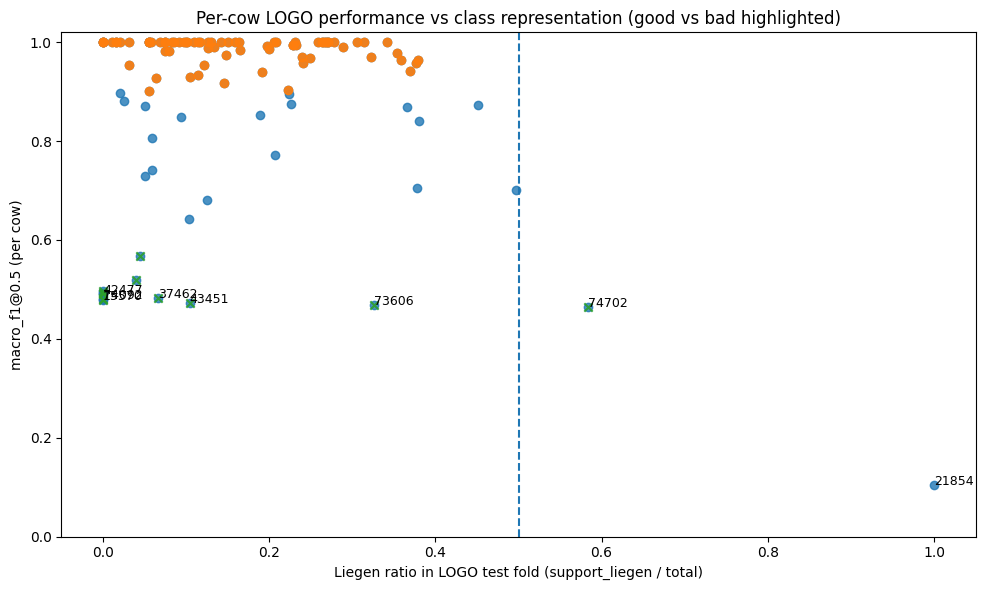

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(cow_metrics["liegen_ratio_in_test"], cow_metrics["macro_f1@0.5"], alpha=0.8)

# Highlight good/bad cows
plt.scatter(
    cow_metrics.loc[cow_metrics["cow_id"].isin(GOOD), "liegen_ratio_in_test"],
    cow_metrics.loc[cow_metrics["cow_id"].isin(GOOD), "macro_f1@0.5"],
    alpha=0.9, marker="o"
)
plt.scatter(
    cow_metrics.loc[cow_metrics["cow_id"].isin(BAD), "liegen_ratio_in_test"],
    cow_metrics.loc[cow_metrics["cow_id"].isin(BAD), "macro_f1@0.5"],
    alpha=0.9, marker="x"
)

plt.axvline(0.5, linestyle="--")
plt.xlabel("Liegen ratio in LOGO test fold (support_liegen / total)")
plt.ylabel("macro_f1@0.5 (per cow)")
plt.ylim(0, 1.02)
plt.title("Per-cow LOGO performance vs class representation (good vs bad highlighted)")

# annotate worst few
worst = cow_metrics.nsmallest(8, "macro_f1@0.5")
for _, r in worst.iterrows():
    plt.text(r["liegen_ratio_in_test"], r["macro_f1@0.5"], str(int(r["cow_id"])), fontsize=9)

plt.tight_layout()
plt.show()


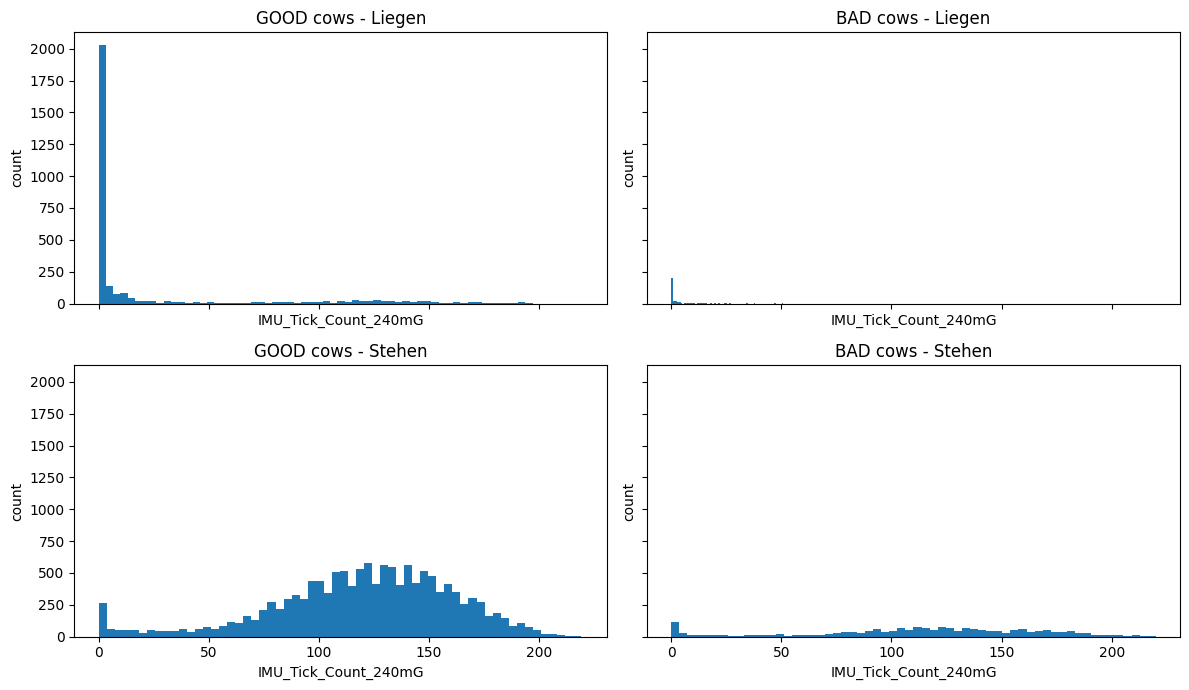

In [23]:
def plot_imu_histograms(raw_good: pd.DataFrame, raw_bad: pd.DataFrame, feature: str, bins: int = 60):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)

    for i, cls in enumerate([0, 1]):  # 0=liegen, 1=stehen
        g0 = raw_good[raw_good[LABEL_COL] == cls][feature].astype(float).to_numpy()
        b0 = raw_bad[raw_bad[LABEL_COL] == cls][feature].astype(float).to_numpy()

        axes[i, 0].hist(g0, bins=bins)
        axes[i, 0].set_title(f"GOOD cows - {'Liegen' if cls==0 else 'Stehen'}")

        axes[i, 1].hist(b0, bins=bins)
        axes[i, 1].set_title(f"BAD cows - {'Liegen' if cls==0 else 'Stehen'}")

    for ax in axes.ravel():
        ax.set_xlabel(feature)
        ax.set_ylabel("count")

    plt.tight_layout()
    plt.show()

plot_imu_histograms(raw_good, raw_bad, "IMU_Tick_Count_240mG")


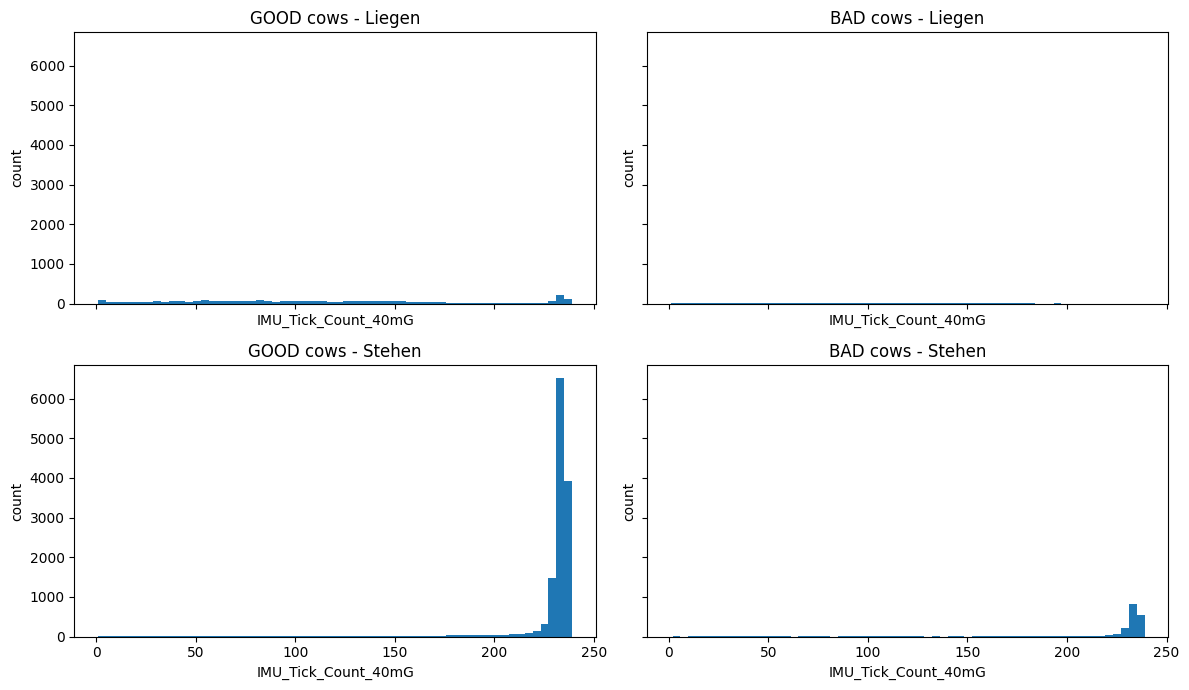

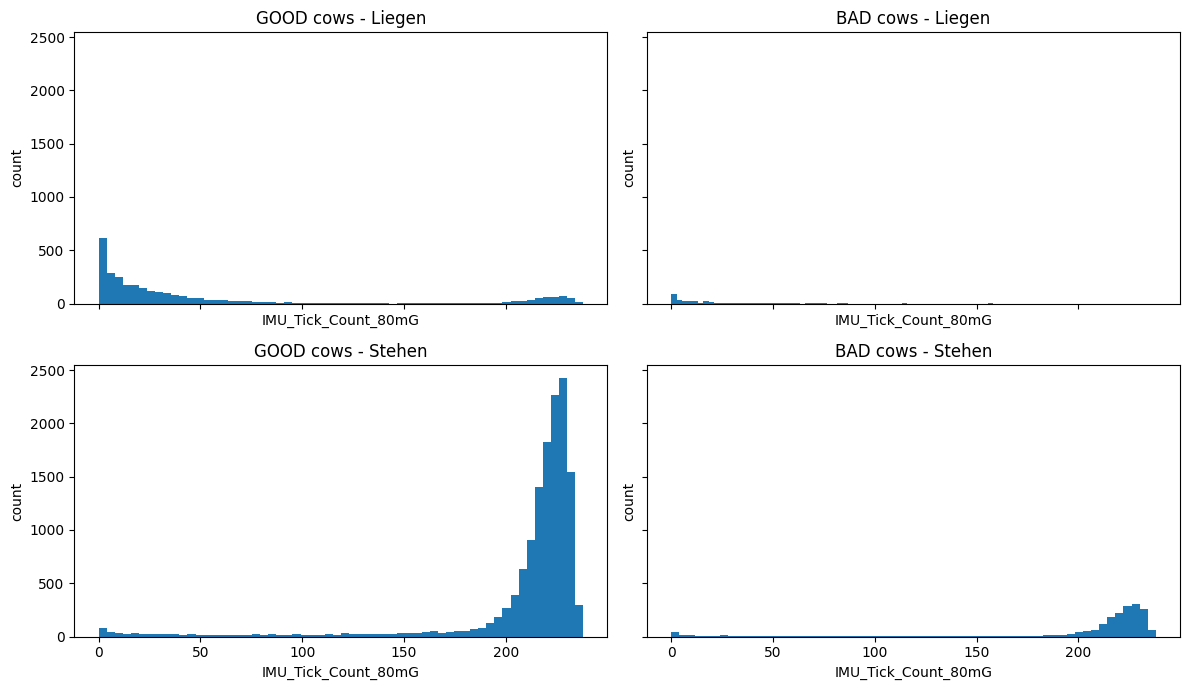

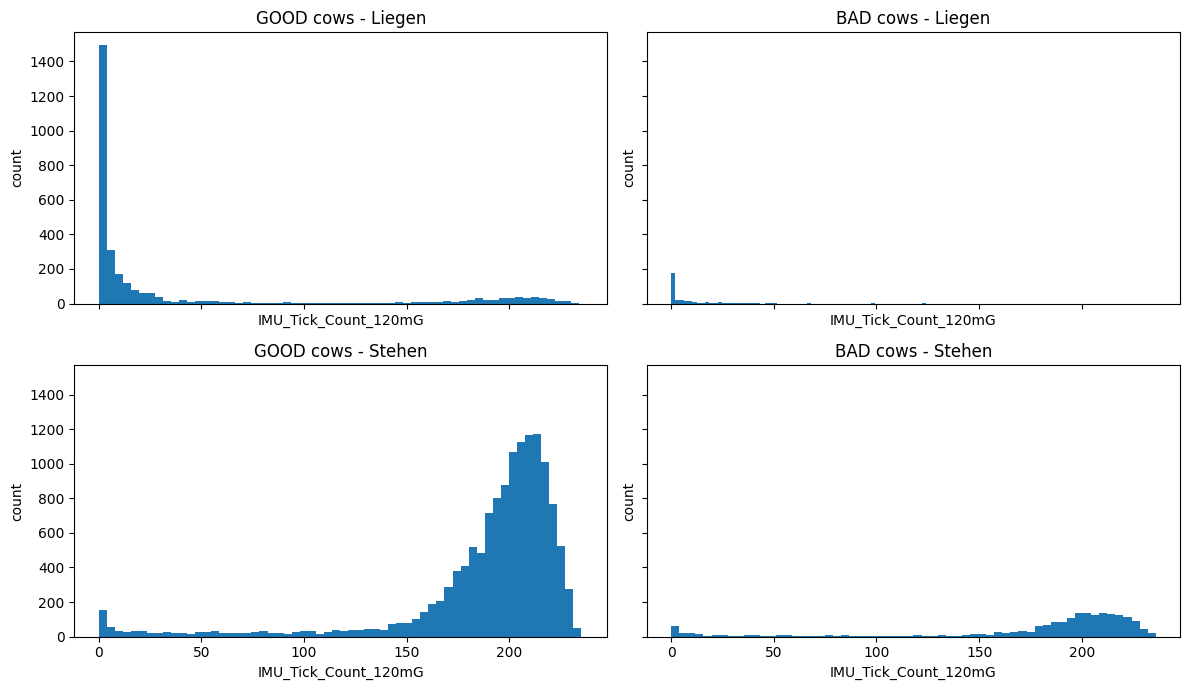

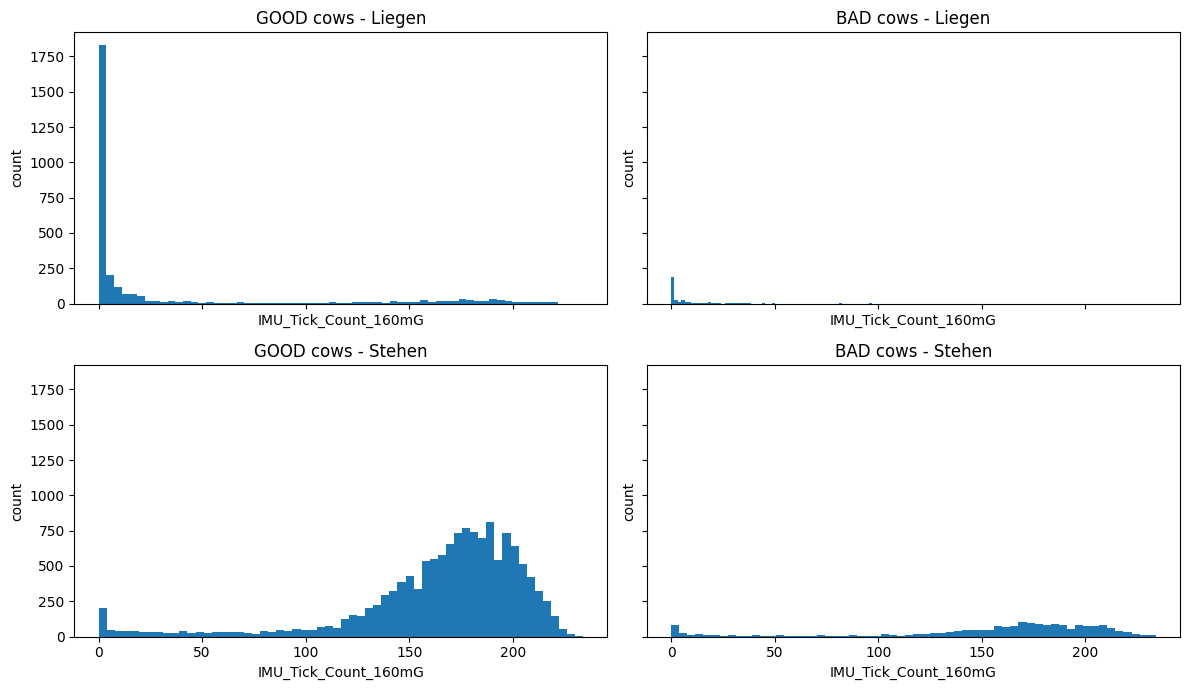

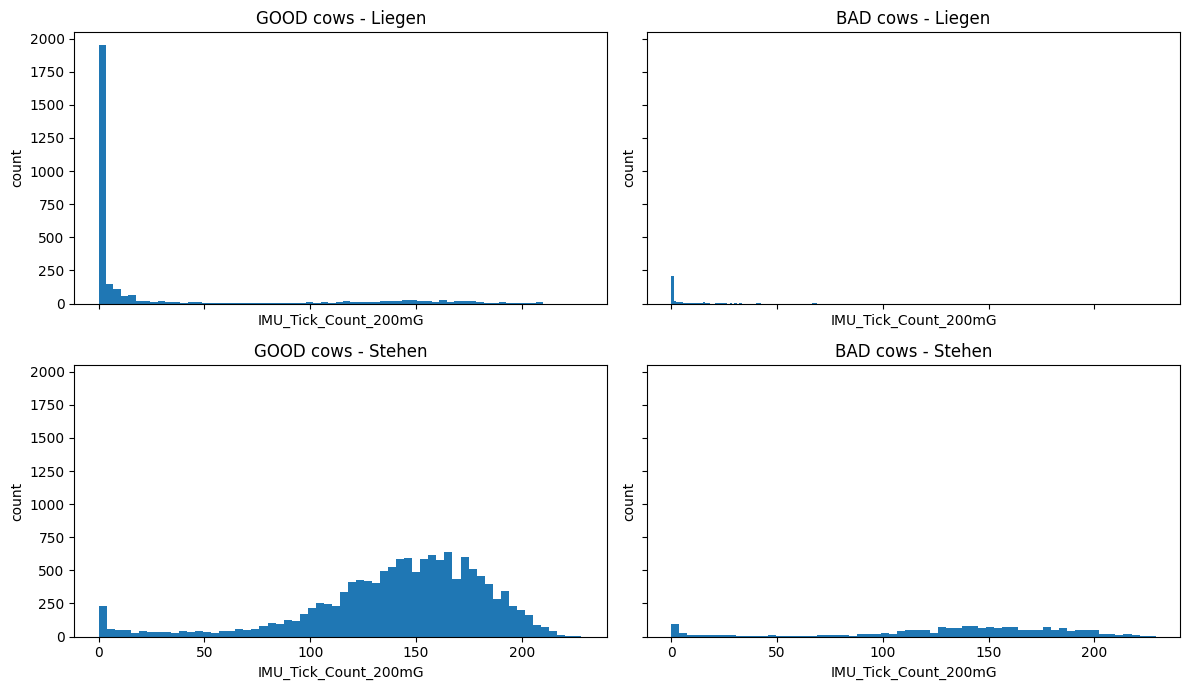

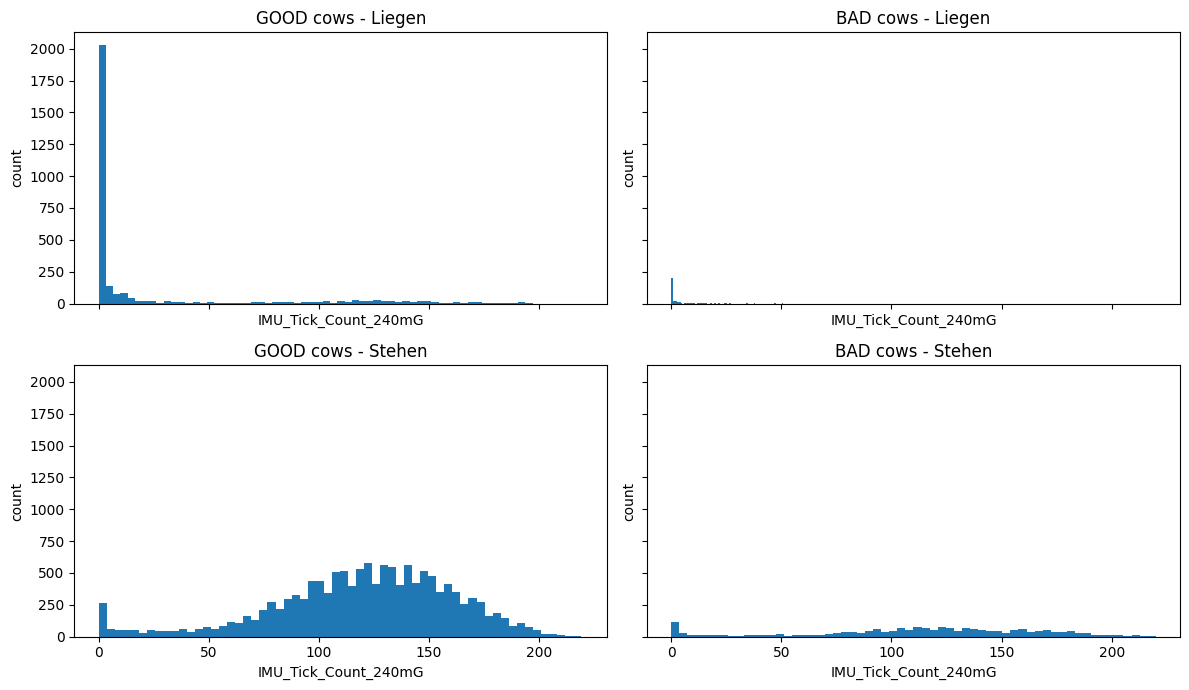

In [24]:
for f in imu_cols:
    plot_imu_histograms(raw_good, raw_bad, f, bins=60)


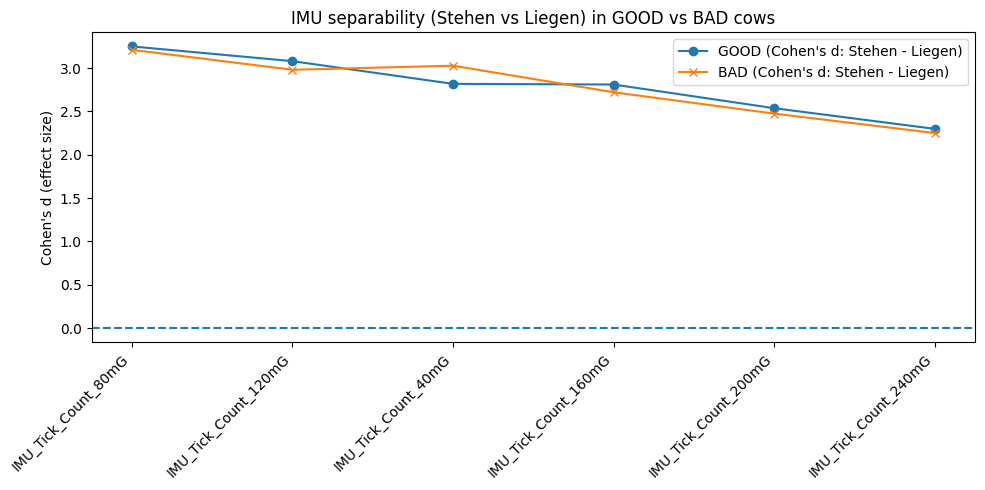

In [25]:
# sep dataframe was computed earlier
sep_plot = sep.copy()

# order features by GOOD effect size magnitude (or use BAD)
order = (
    sep_plot[sep_plot["group"] == "GOOD"]
    .assign(abs_d=lambda x: x["cohens_d"].abs())
    .sort_values("abs_d", ascending=False)["feature"]
    .tolist()
)

x = np.arange(len(order))
good_d = sep_plot[sep_plot["group"] == "GOOD"].set_index("feature").loc[order, "cohens_d"].to_numpy()
bad_d  = sep_plot[sep_plot["group"] == "BAD"].set_index("feature").loc[order, "cohens_d"].to_numpy()

plt.figure(figsize=(10, 5))
plt.plot(x, good_d, marker="o", label="GOOD (Cohen's d: Stehen - Liegen)")
plt.plot(x, bad_d, marker="x", label="BAD (Cohen's d: Stehen - Liegen)")
plt.axhline(0, linestyle="--")
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Cohen's d (effect size)")
plt.title("IMU separability (Stehen vs Liegen) in GOOD vs BAD cows")
plt.legend()
plt.tight_layout()
plt.show()


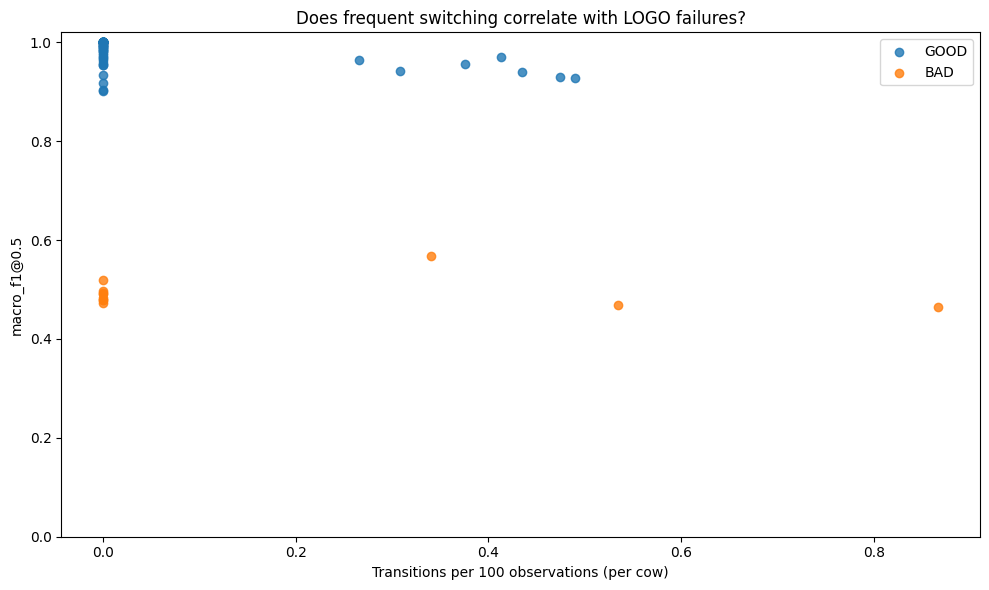

In [26]:
# merged_diag was computed earlier
plt.figure(figsize=(10, 6))
for grp in ["GOOD", "BAD"]:
    g = merged_diag[merged_diag["group"] == grp].dropna(subset=["transitions_per_100", "macro_f1@0.5"])
    plt.scatter(g["transitions_per_100"], g["macro_f1@0.5"], alpha=0.8, label=grp)

plt.xlabel("Transitions per 100 observations (per cow)")
plt.ylabel("macro_f1@0.5")
plt.ylim(0, 1.02)
plt.title("Does frequent switching correlate with LOGO failures?")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
cow_metrics.nsmallest(10, "macro_f1@0.5")

,cow_id,n_obs,stehen_ratio_in_test,macro_f1@0.5,balanced_acc@0.5,f1_liegen@0.5,f1_stehen@0.5,support_liegen,support_stehen,auroc,pr_auc,liegen_ratio_in_test
21,21854,34,0.000000,0.105263,0.117647,0.210526,0.000000,34.0,0.0,NaN,NaN,1.000000
61,74702,346,0.416185,0.464163,0.586634,0.295359,0.632967,202.0,144.0,0.943104,0.936040,0.583815
54,73606,187,0.673797,0.469305,0.532787,0.123077,0.815534,61.0,126.0,0.997398,0.998809,0.326203
52,43451,182,0.895604,0.472464,0.500000,0.000000,0.944928,19.0,163.0,0.906038,0.987787,0.104396
8,15570,201,1.000000,0.479275,0.920398,0.000000,0.958549,0.0,201.0,NaN,NaN,0.000000
60,74092,179,1.000000,0.479651,0.921788,0.000000,0.959302,0.0,179.0,NaN,NaN,0.000000
46,37462,151,0.933775,0.482877,0.500000,0.000000,0.965753,10.0,141.0,1.000000,1.000000,0.066225
50,42477,134,1.000000,0.490494,0.962687,0.000000,0.980989,0.0,134.0,NaN,NaN,0.000000
23,21984,194,1.000000,0.492147,0.969072,0.000000,0.984293,0.0,194.0,NaN,NaN,0.000000
94,99731,140,1.000000,0.496403,0.985714,0.000000,0.992806,0.0,140.0,NaN,NaN,0.000000


In [33]:
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, average_precision_score

cow_id = "74702"  # keep as string to match pred["cow_id"]
g = pred[pred["cow_id"].astype(str) == cow_id].copy()

y_true = g["y_true"].astype(int).to_numpy()
y_prob = g["y_pred"].astype(float).to_numpy()   # this is P(class=1=Stehen)


In [34]:
def best_threshold_for_macro_f1(y_true, y_prob, grid=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    mask = np.isfinite(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_t = None
    best_f1 = -1.0

    for t in grid:
        y_hat = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_hat, labels=[0, 1], average="macro", zero_division=0)
        if np.isfinite(f1) and f1 > best_f1:
            best_f1 = float(f1)
            best_t = float(t)

    return best_t, best_f1

t_best, f1_best = best_threshold_for_macro_f1(y_true, y_prob)

f1_at_05 = f1_score(y_true, (y_prob >= 0.5).astype(int), labels=[0,1], average="macro", zero_division=0)

print("macro F1 @0.5:", f1_at_05)
print("best threshold:", t_best)
print("best macro F1:", f1_best)


macro F1 @0.5: 0.4641628413780312
best threshold: 0.99
best macro F1: 0.7743780096308186


In [35]:
def cm_at_threshold(y_true, y_prob, t):
    y_hat = (y_prob >= t).astype(int)
    return confusion_matrix(y_true, y_hat, labels=[0, 1])

print("Confusion matrix @0.5 (rows=true [Liegen,Stehen], cols=pred [Liegen,Stehen])")
print(cm_at_threshold(y_true, y_prob, 0.5))

print("\nConfusion matrix @best threshold")
print(cm_at_threshold(y_true, y_prob, t_best))


Confusion matrix @0.5 (rows=true [Liegen,Stehen], cols=pred [Liegen,Stehen])
[[ 35 167]
 [  0 144]]

Confusion matrix @best threshold
[[129  73]
 [  5 139]]


In [36]:
print("AUROC (positive=Stehen=1):", roc_auc_score(y_true, y_prob))
print("PR-AUC (positive=Stehen=1):", average_precision_score(y_true, y_prob))


AUROC (positive=Stehen=1): 0.9431036853685368
PR-AUC (positive=Stehen=1): 0.9360396399884371


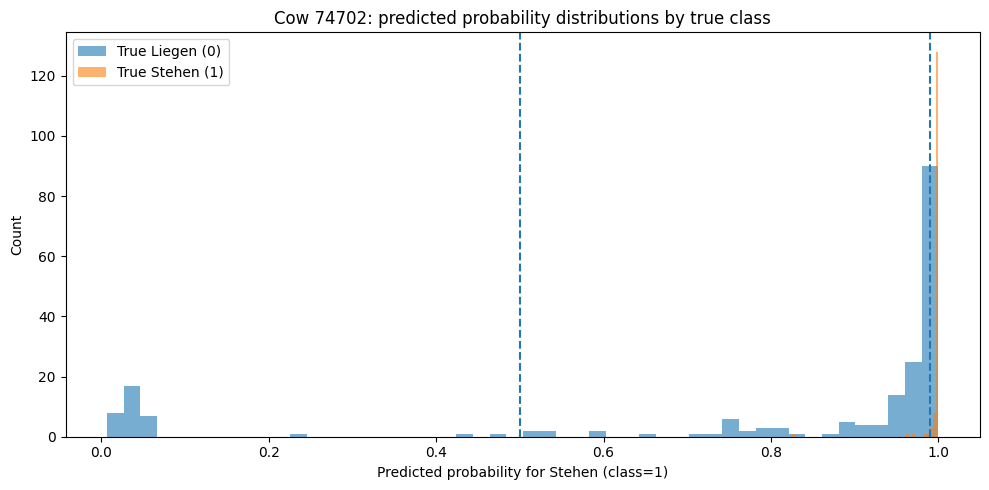

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(y_prob[y_true==0], bins=50, alpha=0.6, label="True Liegen (0)")
plt.hist(y_prob[y_true==1], bins=50, alpha=0.6, label="True Stehen (1)")
plt.axvline(0.5, linestyle="--")
plt.axvline(t_best, linestyle="--")
plt.xlabel("Predicted probability for Stehen (class=1)")
plt.ylabel("Count")
plt.title(f"Cow {cow_id}: predicted probability distributions by true class")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
df.behaviour_2.value_counts(dropna=False)

behaviour_2
Fressen    18256
NaN         2972
KW          2302
Trinken       13
Name: count, dtype: int64

In [43]:
df_beh = df.copy()

df_beh["is_eating"] = df_beh["behaviour_2"] == "Fressen"

# sanity check
df_beh[["behaviour_2", "is_eating"]].value_counts(dropna=False)


behaviour_2  is_eating
Fressen      True         18256
NaN          False         2972
KW           False         2302
Trinken      False           13
Name: count, dtype: int64

In [44]:
COW_COL = "animal_id"
LABEL_COL = "Stehen/Liegen"

def per_cow_eating_stats(dfb: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for cow_id, g in dfb.groupby(COW_COL):
        g = g.dropna(subset=[LABEL_COL])
        standing = g[g[LABEL_COL] == 1]

        if len(standing) == 0:
            continue

        n_standing = len(standing)
        n_eating = standing["is_eating"].sum()

        rows.append({
            "cow_id": str(cow_id),
            "n_standing": n_standing,
            "n_standing_eating": int(n_eating),
            "standing_eating_ratio": n_eating / n_standing,
        })

    return pd.DataFrame(rows)

eat_stats = per_cow_eating_stats(df_beh)
eat_stats.head()


,cow_id,n_standing,n_standing_eating,standing_eating_ratio
0,2452,154,152,0.987013
1,2457,188,188,1.000000
2,2459,187,187,1.000000
3,2460,207,186,0.898551
4,2461,262,187,0.713740


In [46]:
cow_metrics['cow_id'] = cow_metrics['cow_id'].astype(str)

merged = cow_metrics.merge(
    eat_stats,
    on="cow_id",
    how="left"
)

merged["standing_eating_ratio"] = merged["standing_eating_ratio"].fillna(0.0)
merged.head()


,cow_id,n_obs,stehen_ratio_in_test,macro_f1@0.5,balanced_acc@0.5,f1_liegen@0.5,f1_stehen@0.5,support_liegen,support_stehen,auroc,pr_auc,liegen_ratio_in_test,n_standing,n_standing_eating,standing_eating_ratio
0,15543,258,0.728682,1.000000,1.000000,1.000000,1.000000,70.0,188.0,1.000000,1.000000,0.271318,188.0,188.0,1.000000
1,15546,255,0.741176,1.000000,1.000000,1.000000,1.000000,66.0,189.0,1.000000,1.000000,0.258824,189.0,189.0,1.000000
2,15547,321,0.619938,0.840226,0.819672,0.780000,0.900452,122.0,199.0,0.997158,0.998354,0.380062,199.0,171.0,0.859296
3,15554,352,0.548295,0.872351,0.865888,0.845878,0.898824,159.0,193.0,0.992081,0.994637,0.451705,193.0,186.0,0.963731
4,15555,204,0.936275,0.928042,0.989529,0.866667,0.989418,13.0,191.0,0.987112,0.999166,0.063725,191.0,187.0,0.979058


In [50]:
GOOD = [str(c) for c in GOOD]
BAD  = [str(c) for c in BAD]

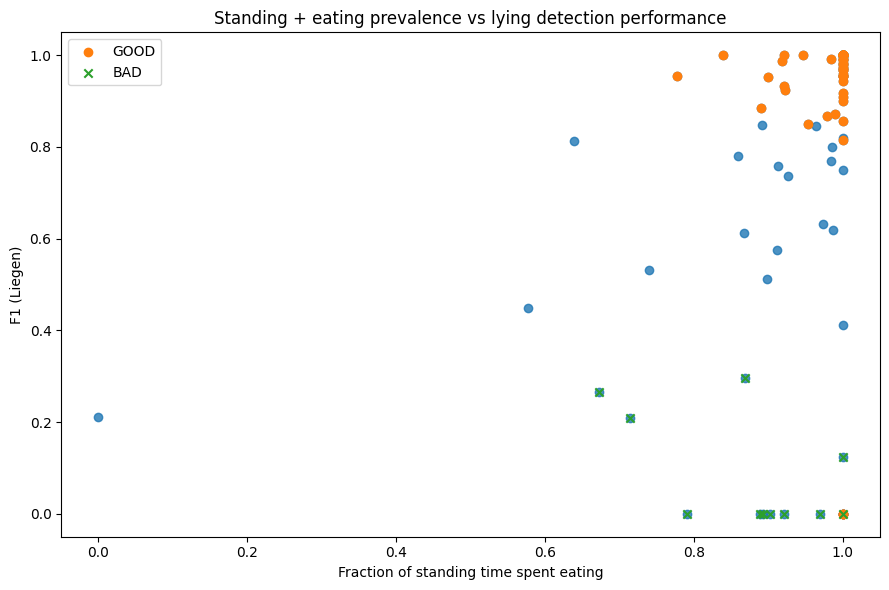

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.scatter(
    merged["standing_eating_ratio"],
    merged["f1_liegen@0.5"],
    alpha=0.8
)

# highlight GOOD / BAD
plt.scatter(
    merged.loc[merged["cow_id"].isin(GOOD), "standing_eating_ratio"],
    merged.loc[merged["cow_id"].isin(GOOD), "f1_liegen@0.5"],
    label="GOOD",
    marker="o"
)

plt.scatter(
    merged.loc[merged["cow_id"].isin(BAD), "standing_eating_ratio"],
    merged.loc[merged["cow_id"].isin(BAD), "f1_liegen@0.5"],
    label="BAD",
    marker="x"
)

plt.xlabel("Fraction of standing time spent eating")
plt.ylabel("F1 (Liegen)")
plt.title("Standing + eating prevalence vs lying detection performance")
plt.legend()
plt.tight_layout()
plt.show()


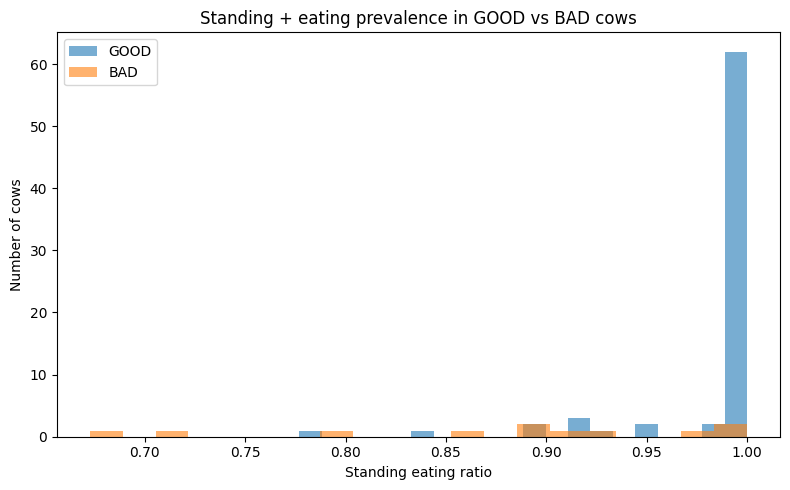

In [52]:
plt.figure(figsize=(8,5))

plt.hist(
    merged.loc[merged["cow_id"].isin(GOOD), "standing_eating_ratio"],
    bins=20, alpha=0.6, label="GOOD"
)

plt.hist(
    merged.loc[merged["cow_id"].isin(BAD), "standing_eating_ratio"],
    bins=20, alpha=0.6, label="BAD"
)

plt.xlabel("Standing eating ratio")
plt.ylabel("Number of cows")
plt.title("Standing + eating prevalence in GOOD vs BAD cows")
plt.legend()
plt.tight_layout()
plt.show()
